In [4]:
# LIBRERÍAS

import pandas as pd

In [5]:
df = pd.read_csv("../data/raw/screen_time_mental_health.csv")
df.head()

,subject_id,sex,screen_time_index,est_leisure_screen_hours,sleep_quality_index,avg_sleep_hours,midsleep_weekend_hours,social_jetlag_hours,bdi_total,depressed
0,1,Boy,3.333,4.64,2.25,8.36,4.58,1.92,6,0
1,2,Girl,3.333,4.07,2.50,7.31,5.42,2.25,7,0
2,3,Boy,3.333,4.07,2.00,8.75,5.50,2.62,27,1
3,4,Boy,4.333,6.07,1.50,8.17,6.62,3.96,22,1
4,5,Boy,1.667,0.50,2.50,8.88,4.12,1.79,3,0


## Desarrollo de EDA completo

### Paso 1 EDA: Planteamiento del problema

Buscamos una manera de predecir el nivel de síntomas depresivos en adolescentes para general una alerta temprana a sus padres a partir de algunos de sus hábitos.

Nuestra variable objetivo será: ***'bdi_total'*** 

### Paso 2 EDA: Exploración y limpieza de datos

In [6]:
df.shape

(4810, 10)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4810 entries, 0 to 4809
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   subject_id                4810 non-null   int64  
 1   sex                       4810 non-null   str    
 2   screen_time_index         4810 non-null   float64
 3   est_leisure_screen_hours  4810 non-null   float64
 4   sleep_quality_index       4810 non-null   float64
 5   avg_sleep_hours           4810 non-null   float64
 6   midsleep_weekend_hours    4810 non-null   float64
 7   social_jetlag_hours       4810 non-null   float64
 8   bdi_total                 4810 non-null   int64  
 9   depressed                 4810 non-null   int64  
dtypes: float64(6), int64(3), str(1)
memory usage: 375.9 KB


Nuestro dataframe tiene 4810 observaciones y 10 variables. Para el modelo de regresión, vamos a tomar como variable dependiente 'bdi_total' y como predictoras todas las restantes a excepción de dos: 'subject_id', que no debería utilizarse como predictor porque es simplemente un identificador, y 'depressed', que tampoco conviene incluirlo si es una variable construida a partir de 'bdi_total', porque produciría fuga de información. Todas nuestras variables son numéricas menos una: 'sex', que es categórica. Por otro lado podemos ver que no hay valores nulos, y que el número de filas es de 4810, que corresponden al número de niños de entre 12 y 16 años consultados

Ahora procedemos a analizar si hay duplicados y en su caso, a eliminarlos:

In [ ]:
df.duplicated().sum()

Podemos corroborar que no hay duplicados.

In [10]:
df.columns

Index(['sex', 'screen_time_index', 'est_leisure_screen_hours',
       'sleep_quality_index', 'avg_sleep_hours', 'midsleep_weekend_hours',
       'social_jetlag_hours', 'bdi_total'],
      dtype='str')

In [8]:

df = df.drop(columns=["subject_id", "depressed"])


Excluímos ambas variables mencionadas del df.

### Paso 3 EDA: Análisis de variables univariante


Tenemos que convertir nuestra variable categórica en numérica, porque un modelo de Regresión Lineal necesita trabajar valores numéricos. Como 'sex' tiene sólo dos categorías, la convertimos en una variable binaria.

In [11]:
df["sex"].value_counts()

sex
Boy     2446
Girl    2364
Name: count, dtype: int64

In [12]:
df["sex"] = df["sex"].map({
    "Boy": 0,
    "Girl": 1
})

In [13]:
print(df["sex"].value_counts())

sex
0    2446
1    2364
Name: count, dtype: int64


Podemos ver que casi la mitad de las filas corresponden a encuestados de sexo masculino y el otro 50 a femenino. Hay un poco más de hombres encuestados, pero valores equilibrados de cada sexo.

**Análisis sobre variables numéricas**

Normalmente se representan utilizando un histograma y diagramas de caja, expuestos juntos. En nuestro Dataset todas las variables son numéricas, ya que a la única categórica ('sex') la transformamos y quedó categórica numérica (Girl/Boy).

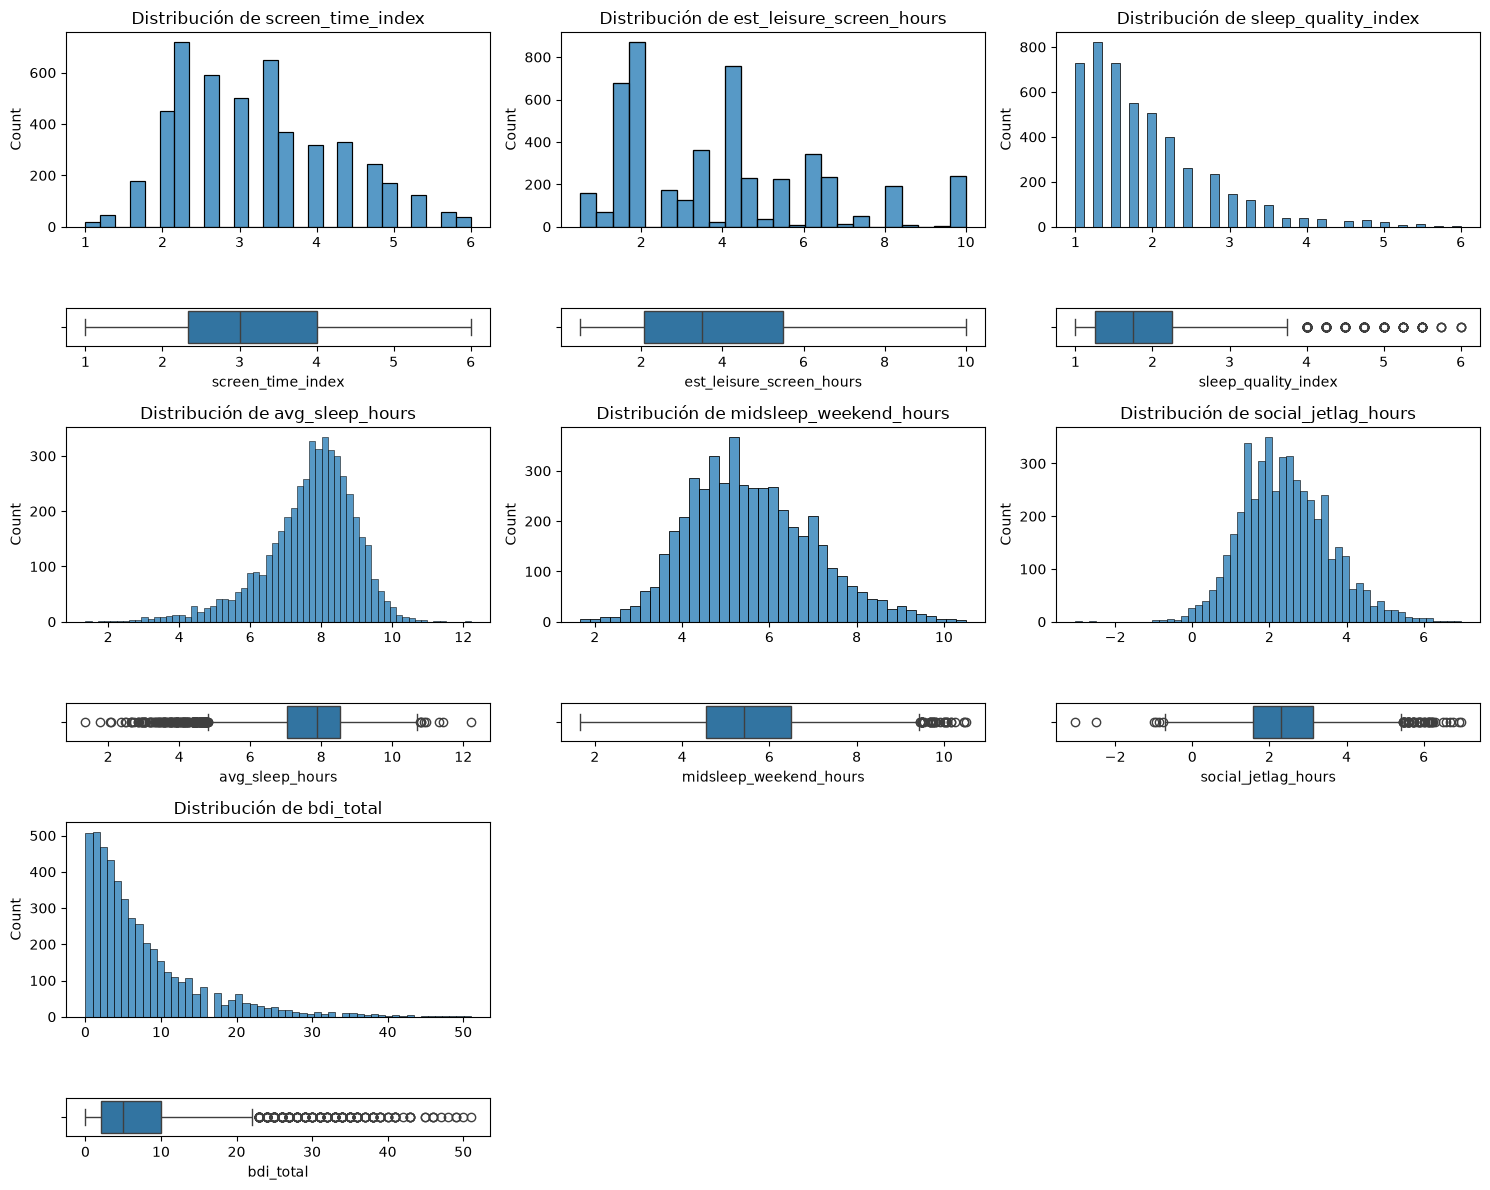

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

variables = [
    "screen_time_index",
    "est_leisure_screen_hours",
    "sleep_quality_index",
    "avg_sleep_hours",
    "midsleep_weekend_hours",
    "social_jetlag_hours",
    "bdi_total"
]

# 3 gráficos por fila
ncols = 3
nrows = (len(variables) + ncols - 1) // ncols

fig, axis = plt.subplots(
    nrows=2 * nrows,
    ncols=ncols,
    figsize=(15, 4 * nrows),
    gridspec_kw={"height_ratios": [5, 1] * nrows}
)

# Recorrer las variables
for i, variable in enumerate(variables):

    # Calcular fila y columna
    col = i % ncols
    row = (i // ncols) * 2

    # Histograma
    sns.histplot(
        data=df,
        x=variable,
        ax=axis[row, col]
    )

    axis[row, col].set_title(f"Distribución de {variable}")
    axis[row, col].set_xlabel("")
    
    # Boxplot
    sns.boxplot(
        data=df,
        x=variable,
        ax=axis[row + 1, col]
    )

    axis[row + 1, col].set_xlabel(variable)

# Ocultar espacios vacíos
for i in range(len(variables), nrows * ncols):
    col = i % ncols
    row = (i // ncols) * 2
    
    axis[row, col].set_visible(False)
    axis[row + 1, col].set_visible(False)

# Ajustar espacios
plt.tight_layout()

# Mostrar gráficos
plt.show()

- **screen_time_index:** presenta una distribución relativamente compacta/normal y no muestra una cantidad preocupante de valores atípicos.La distribución está bastante concentrada entre aproximadamente 2 y 4. Tiene cierta dispersión hacia valores mayores, llegando aproximadamente a 6. El boxplot no muestra una cantidad excesiva de valores atípicos. Por lo tanto, inicialmente parece una variable adecuada para utilizar como predictor en el modelo de regresión lineal.

- **est_leisure_screen_hours:** presenta una distribución multimodal, con concentraciones en determinados valores, No parece una distribución normal. Se observan concentraciones en distintos valores, especialmente alrededor de 2, 4, 6, 8 y 10 horas. Eso podría indicar que la variable está discretizada o que los datos fueron registrados en determinados intervalos. Esto no impide utilizarla como predictor en una regresión lineal, pero será necesario analizar posteriormente su relación con bdi_total para comprobar si existe una relación aproximadamente lineal.

- **sleep_quality_index:** Esta variable presenta una distribución fuertemente asimétrica hacia la derecha. La mayoría de los valores están concentrados aproximadamente entre 1 y 3, mientras que hay algunos valores bastante mayores. Presenta una distribución asimétrica y una cantidad considerable de valores extremos. Estos valores deberán ser analizados para determinar si corresponden a observaciones válidas o a errores. No se recomienda eliminarlos automáticamente.

- **avg_sleep_hours:** Esta es una de las variables que visualmente presenta una distribución más cercana a una campana. La mayor concentración está aproximadamente alrededor de 7–9 horas.Hay personas con valores de sueño muy bajos y algunas con valores superiores a 10 horas. Sin embargo, el boxplot muestra valores extremos tanto por debajo como por encima del rango central. Presenta una distribución aproximadamente unimodal y relativamente cercana a una distribución normal, aunque existen algunos valores extremos. En principio, parece una variable adecuada para el modelo, pero los valores atípicos deberán ser revisados.

- **midsleep_weekend_hours:** Esta variable presenta una distribución bastante interesante. Tiene una concentración importante alrededor de 4–7 horas, con cierta asimetría hacia la derecha. El boxplot muestra varios valores extremos en la parte superior. Presenta una distribución relativamente continua, aunque con algunos valores extremos. Estos valores no deberían eliminarse automáticamente, ya que podrían representar horarios de sueño reales.

- **social_jetlag_hours:** La distribución tiene una forma aproximadamente unimodal, concentrándose alrededor de 1–3 horas. También presenta algunos valores negativos y valores extremos positivos. Esto tiene sentido conceptualmente porque el social jetlag representa la diferencia entre horarios de sueño y puede tomar distintos valores según cómo se haya calculado. Presenta una distribución relativamente concentrada, aunque existen valores extremos en ambos sentidos. Será necesario comprobar que dichos valores sean válidos y analizar posteriormente su relación con bdi_total.

- **bdi_total:** Esta es la variable más importante, porque es nuestra variable objetivo y. Y aquí encontramos algo que tenemos que destacar. La distribución está fuertemente sesgada hacia la derecha, hay una gran concentración de personas con valores bajos de bdi_total y cada vez menos observaciones a medida que aumenta el puntaje. Además, el boxplot muestra numerosos valores que aparecen como outliers, llegando aproximadamente hasta 50. Si bdi_total es un puntaje válido del instrumento utilizado, esos valores altos pueden representar personas con mayores niveles de síntomas. No son necesariamente errores.

**Por lo tanto:**

'bdi_total' presenta una distribución fuertemente asimétrica hacia la derecha y una cantidad importante de valores extremos. Debido a que estos valores representan puntajes reales del fenómeno estudiado, no deberían eliminarse automáticamente. Será necesario evaluar posteriormente su impacto sobre el modelo de regresión.

Y como ya vimos en el histograma más arriba en la parte de análisis descriptivo, la variable 'sex' está bastante equilibrada, con una cantidad similar de observaciones en las categorías 0 y 1. Por lo tanto, no se observa un desbalance significativo que pueda afectar al modelo de regresión.

**Análisis de variables multivariante**

Tras analizar las características una a una, es momento de analizarlas en relación con la predictora y con ellas mismas, para sacar conclusiones más claras acerca de sus relaciones y poder tomar decisiones sobre su procesamiento.

Análisis numérico-numérico

Para comparar dos columnas numéricas se utilizan diagramas de dispersión y análisis de correlaciones.

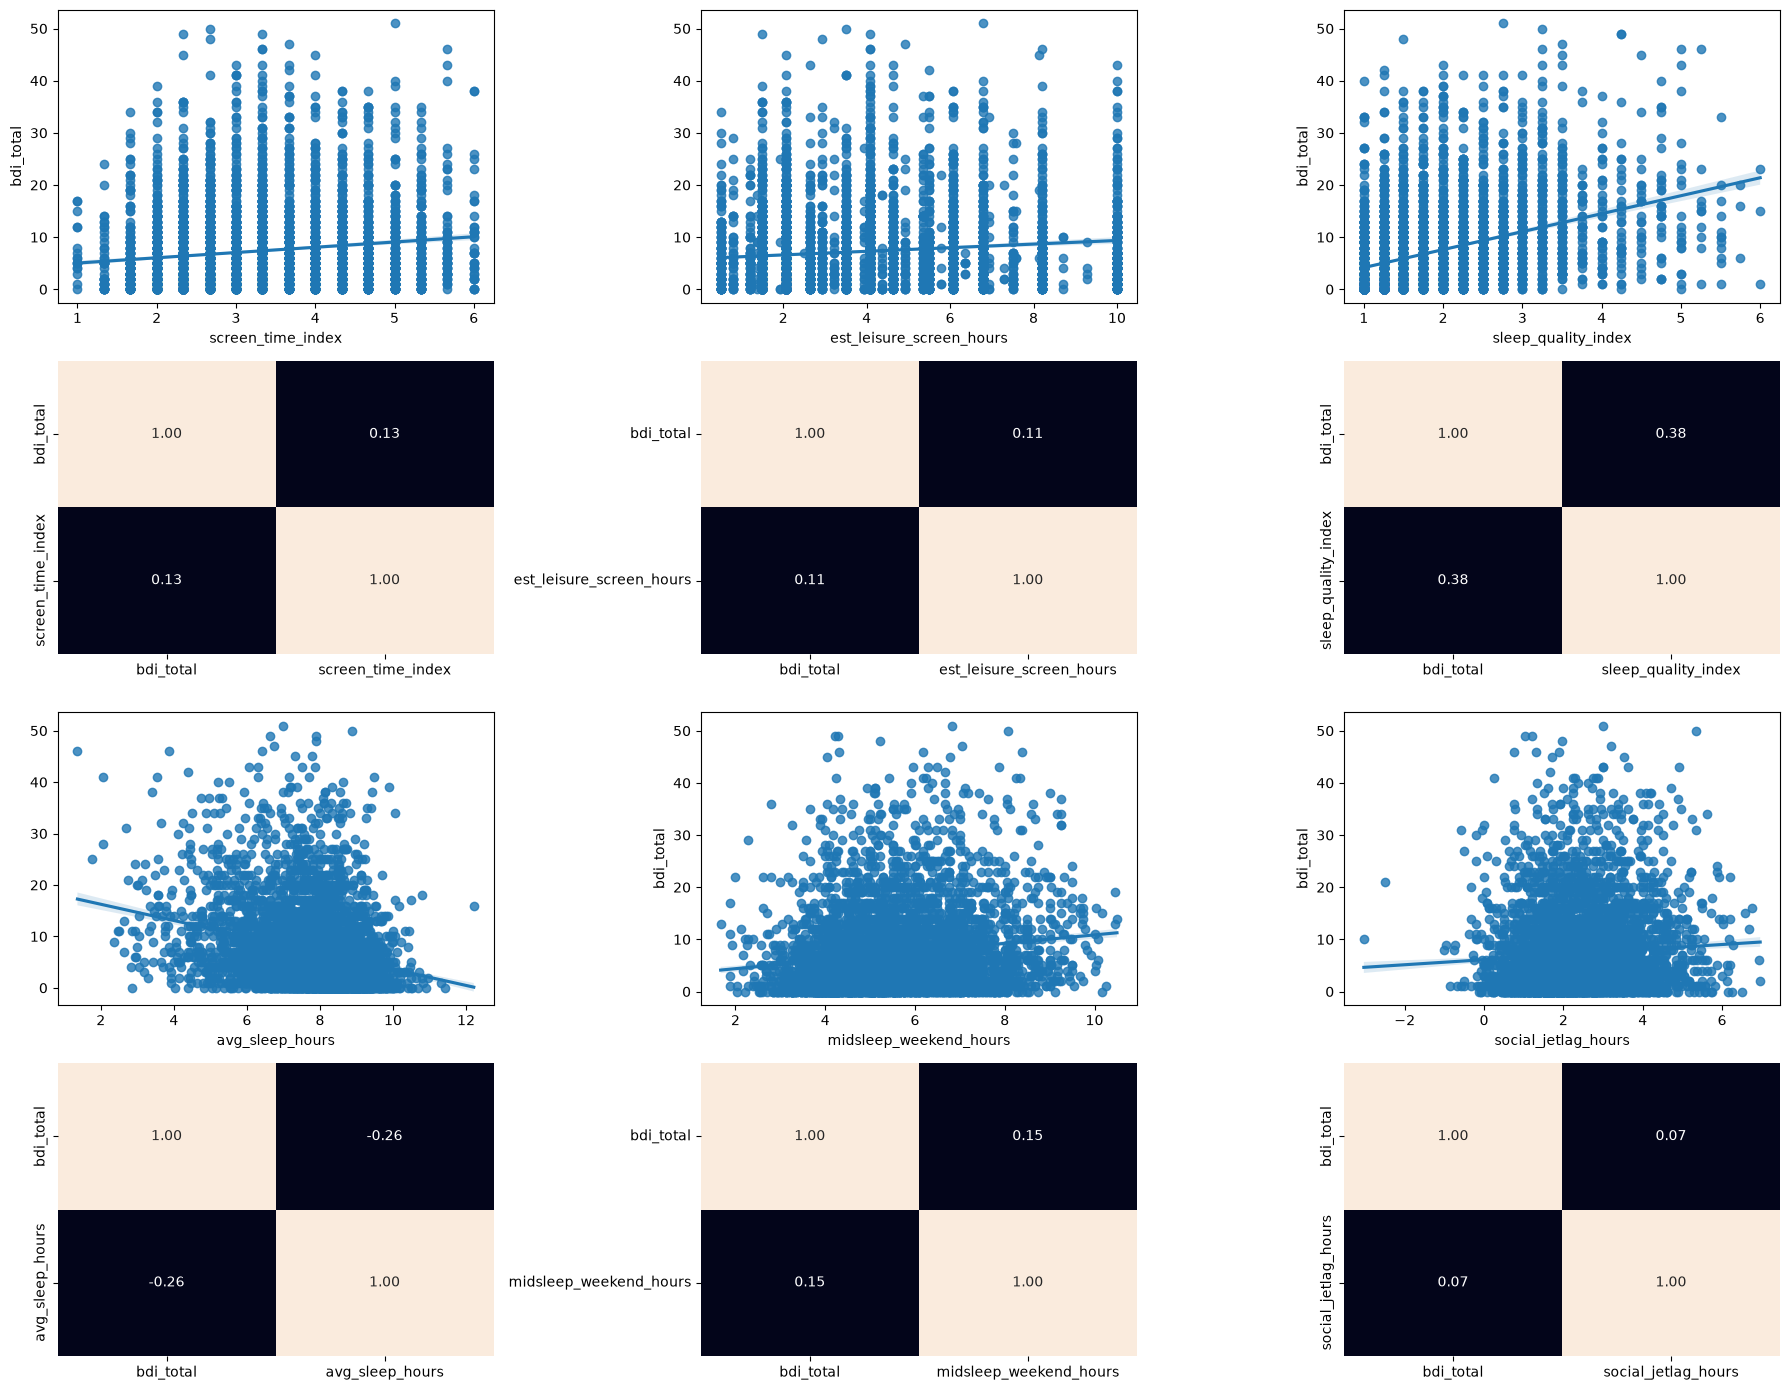

In [22]:
fig, axis = plt.subplots(4, 3, figsize=(18, 14))

# screen_time_index
sns.regplot(
    ax=axis[0, 0],
    data=df,
    x="screen_time_index",
    y="bdi_total"
)

sns.heatmap(
    df[["bdi_total", "screen_time_index"]].corr(),
    annot=True,
    fmt=".2f",
    ax=axis[1, 0],
    cbar=False
)

# est_leisure_screen_hours
sns.regplot(
    ax=axis[0, 1],
    data=df,
    x="est_leisure_screen_hours",
    y="bdi_total"
).set(ylabel=None)

sns.heatmap(
    df[["bdi_total", "est_leisure_screen_hours"]].corr(),
    annot=True,
    fmt=".2f",
    ax=axis[1, 1],
    cbar=False
)

# sleep_quality_index
sns.regplot(
    ax=axis[0, 2],
    data=df,
    x="sleep_quality_index",
    y="bdi_total"
)

sns.heatmap(
    df[["bdi_total", "sleep_quality_index"]].corr(),
    annot=True,
    fmt=".2f",
    ax=axis[1, 2],
    cbar=False
)

# avg_sleep_hours
sns.regplot(
    ax=axis[2, 0],
    data=df,
    x="avg_sleep_hours",
    y="bdi_total"
).set(ylabel=None)

sns.heatmap(
    df[["bdi_total", "avg_sleep_hours"]].corr(),
    annot=True,
    fmt=".2f",
    ax=axis[3, 0],
    cbar=False
)

# midsleep_weekend_hours
sns.regplot(
    ax=axis[2, 1],
    data=df,
    x="midsleep_weekend_hours",
    y="bdi_total"
)

sns.heatmap(
    df[["bdi_total", "midsleep_weekend_hours"]].corr(),
    annot=True,
    fmt=".2f",
    ax=axis[3, 1],
    cbar=False
)

# social_jetlag_hours
sns.regplot(
    ax=axis[2, 2],
    data=df,
    x="social_jetlag_hours",
    y="bdi_total"
)

sns.heatmap(
    df[["bdi_total", "social_jetlag_hours"]].corr(),
    annot=True,
    fmt=".2f",
    ax=axis[3, 2],
    cbar=False
)

# Ajustar el layout
plt.tight_layout()

# Mostrar el plot
plt.show()

Los diagramas de correlación permiten identificar la dirección y la intensidad de la relación lineal entre las variables predictoras y el nivel de síntomas depresivos (bdi_total). Estas correlaciones sirven como análisis exploratorio previo al modelo de regresión, permitiendo detectar variables potencialmente relevantes y posibles problemas de multicolinealidad entre las predictoras.

Los diagramas de dispersión y las matrices de correlación muestran que ninguna de las variables predictoras presenta una relación lineal fuerte con bdi_total. La mayor asociación corresponde a sleep_quality_index (r = 0.38), seguida de avg_sleep_hours (r = -0.26). Las variables relacionadas con el uso de pantallas presentan correlaciones débiles (screen_time_index = 0.13; est_leisure_screen_hours = 0.11), mientras que social_jetlag_hours muestra una asociación prácticamente nula (r = 0.07). Estos resultados sugieren que las variables podrían aportar información al modelo de regresión de manera conjunta, aunque ninguna parece explicar por sí sola una proporción elevada de la variabilidad de los síntomas depresivos.

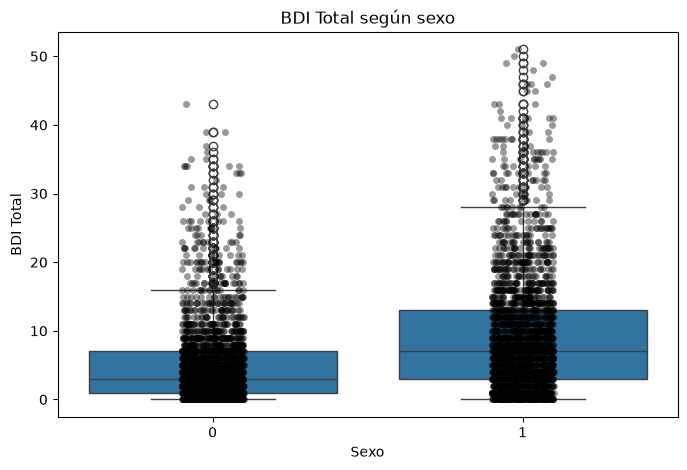

In [16]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="sex", y="bdi_total")
sns.stripplot(data=df, x="sex", y="bdi_total", color="black", alpha=0.4)

plt.title("BDI Total según sexo")
plt.xlabel("Sexo")
plt.ylabel("BDI Total")

plt.show()

Este diseño de boxplot nos permite mostrar los puntos individuales para ver mejor la distribución.

Se observa una diferencia en la distribución de bdi_total según el sexo. El grupo 0 (Girl) presenta una mediana de BDI Total más alta que el grupo 1 (Boy), aproximadamente 7 frente a 3 puntos. Además, el grupo 0 muestra mayor dispersión, con valores de BDI más elevados y un rango intercuartílico más amplio.

Ambos grupos presentan numerosos valores atípicos altos, lo que indica que existen participantes con niveles de síntomas depresivos considerablemente superiores al resto.

El grupo 0 alcanza valores atípicos de BDI de aproximadamente 50 puntos, mientras que el grupo 1 llega hasta alrededor de 43. Por lo tanto, sex podría ser una variable relevante para explicar bdi_total en el modelo de regresión, aunque sería necesario realizar un análisis estadístico para determinar si la diferencia observada es significativa.

Conclusión: El boxplot muestra que existen diferencias en los niveles de bdi_total entre ambos grupos de sexo. El grupo 0 presenta una mediana y una variabilidad mayores, además de valores extremos más elevados. Esto sugiere que el sexo podría estar asociado con los síntomas depresivos y ser una variable potencialmente relevante para el modelo de regresión.

### Combinaciones de la clase con varias predictoras

El análisis multivariante también permite combinar la clase con varias predictoras al mismo tiempo para enriquecer el análisis.

### Correlación de Pearson + p-value: 

Correlación únicamente entre variables numéricas (Pearson), para estudiar las relaciones lineales entre bdi_total y cada predictora.

In [18]:
from scipy.stats import pearsonr

variables_predictoras = [
    "screen_time_index",
    "est_leisure_screen_hours",
    "sleep_quality_index",
    "avg_sleep_hours",
    "midsleep_weekend_hours",
    "social_jetlag_hours"
]

for variable in variables_predictoras:
    r, p = pearsonr(df[variable], df["bdi_total"])
    
    print(f"{variable}:")
    print(f"  Pearson r = {r:.4f}")
    print(f"  p-value = {p:.4e}")
    print()

screen_time_index:
  Pearson r = 0.1344
  p-value = 8.0001e-21

est_leisure_screen_hours:
  Pearson r = 0.1072
  p-value = 9.1693e-14

sleep_quality_index:
  Pearson r = 0.3806
  p-value = 1.3167e-165

avg_sleep_hours:
  Pearson r = -0.2603
  p-value = 2.6337e-75

midsleep_weekend_hours:
  Pearson r = 0.1488
  p-value = 3.3070e-25

social_jetlag_hours:
  Pearson r = 0.0717
  p-value = 6.4785e-07



El análisis de correlación de Pearson mostró que todas las variables predictoras presentan una asociación lineal estadísticamente significativa con bdi_total (p < 0,05). La mayor correlación se observó con sleep_quality_index (r = 0,381), indicando una asociación positiva moderada. Por otro lado, avg_sleep_hours presentó una asociación negativa débil-moderada (r = −0,260). Las restantes variables mostraron asociaciones positivas débiles o muy débiles, siendo social_jetlag_hours la de menor magnitud (r = 0,072). **Estos resultados indican que las variables relacionadas con el sueño presentan las asociaciones lineales más relevantes con el nivel de BDI, aunque las correlaciones no implican causalidad.**



**Análisis Numérico - Categórico**

Vamos a analizar la variable categórica binaria 'sex' con la variable objetivo.

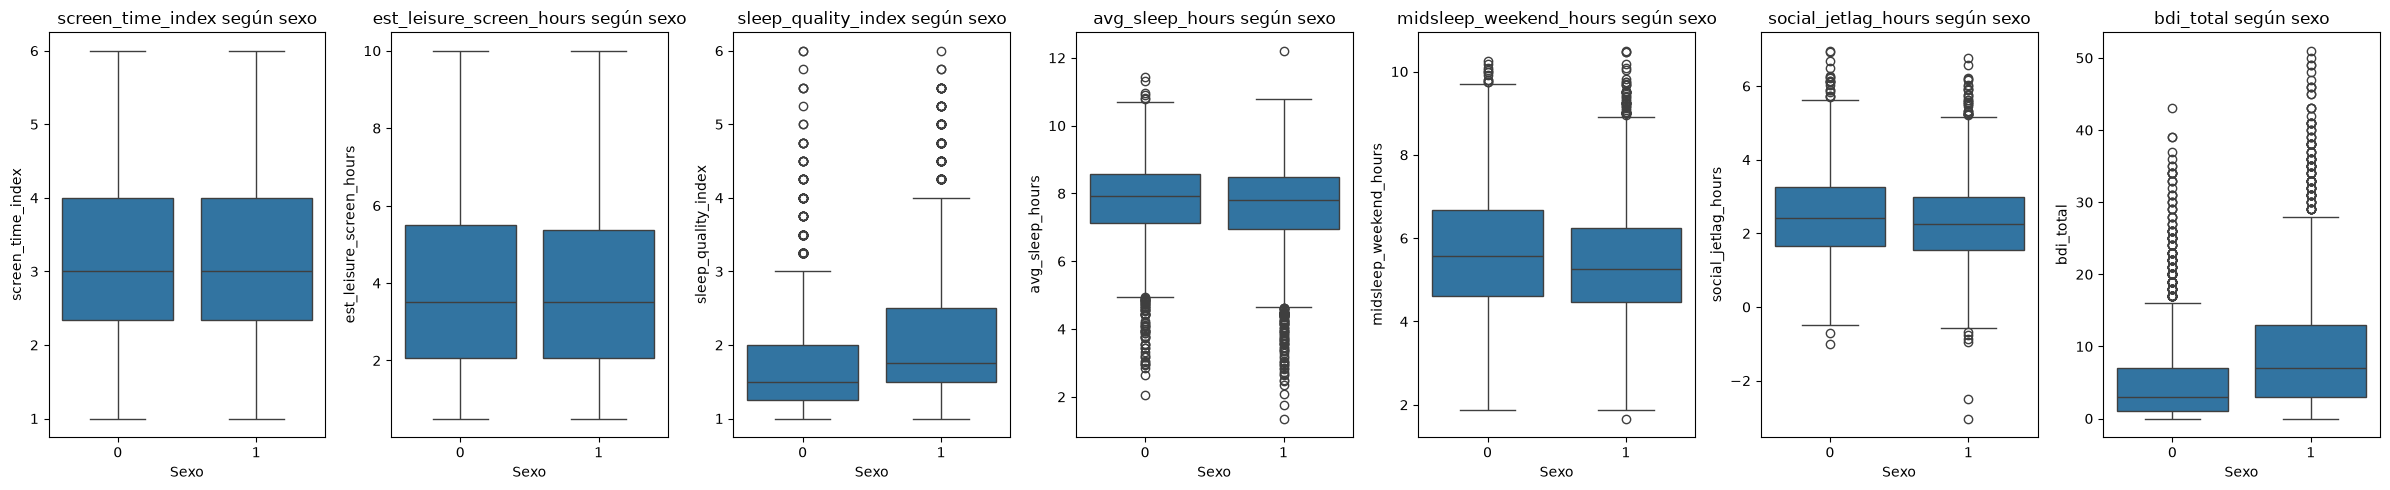

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

# Variables numéricas a analizar
variables = [
    "screen_time_index",
    "est_leisure_screen_hours",
    "sleep_quality_index",
    "avg_sleep_hours",
    "midsleep_weekend_hours",
    "social_jetlag_hours",
    "bdi_total"
]

# Crear gráficos uno al lado del otro
fig, axes = plt.subplots(1, len(variables), figsize=(24, 5))

for ax, variable in zip(axes, variables):
    sns.boxplot(
        data=df,
        x="sex",
        y=variable,
        ax=ax
    )
    
    ax.set_title(f"{variable} según sexo")
    ax.set_xlabel("Sexo")
    ax.set_ylabel(variable)

plt.tight_layout()
plt.show()

Conclusiones de nuestros boxplots:

- Screen time: No se observan diferencias relevantes entre sexos; las distribuciones son muy similares.

- Horas de pantalla de ocio: Los valores centrales son prácticamente iguales, aunque existe una dispersión considerable en ambos grupos.

- Calidad del sueño: Se observa una mediana ligeramente mayor en el grupo 1 (Girls), con numerosos valores atípicos en ambos grupos.

- Horas promedio de sueño: Las distribuciones son similares, aunque el grupo 1 presenta una mediana ligeramente menor.

- Midsleep del fin de semana: El grupo 0 (Boys) presenta una mediana algo mayor que el grupo 1.

- Social jetlag: Las medianas son muy parecidas, con una dispersión similar y varios valores atípicos.

- BDI total: Es la diferencia más evidente: el grupo 1 presenta una mediana de BDI considerablemente mayor y mayor dispersión que el grupo 0.

**Conclusión general: Las variables relacionadas con el uso de pantallas y el sueño presentan distribuciones bastante similares entre sexos, mientras que bdi_total muestra una diferencia visual más marcada entre ambos grupos.**

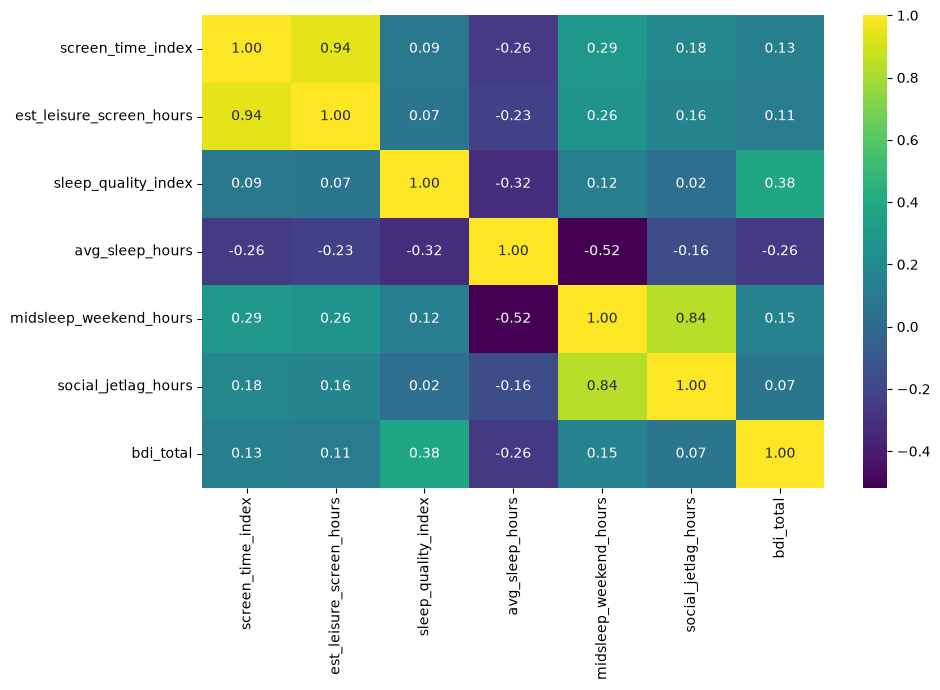

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

cols_num = [
    "screen_time_index",
    "est_leisure_screen_hours",
    "sleep_quality_index",
    "avg_sleep_hours",
    "midsleep_weekend_hours",
    "social_jetlag_hours",
    "bdi_total"
]

fig, ax = plt.subplots(figsize=(10, 7))

sns.heatmap(
    df[cols_num].corr(method="pearson"),
    annot=True,
    fmt=".2f",
    cmap="viridis",
    ax=ax
)

plt.tight_layout()
plt.show()

- **screen_time_index** y **est_leisure_screen_hours** presentan una correlación muy fuerte y positiva (r = 0,94), indicando que ambas variables están muy relacionadas. Se observa posible multicolinealidad, por lo que vamos a descartar **est_leisure_screen_hours** dejando la primera para nuestro modelo.


- **midsleep_weekend_hours** y **social_jetlag_hours** también muestran una correlación fuerte y positiva (r = 0,84). Vamos a decartar la segunda, dejando la primera por multicolinealidad.


- **sleep_quality_index** y **bdi_total** presentan la mayor correlación con la variable objetivo (r = 0,38), siendo una relación positiva moderada.


- **avg_sleep_hours** y **bdi_total** tienen una relación negativa débil-moderada (r = −0,26): a mayor cantidad de horas de sueño, tiende a disminuir el BDI.


- Las variables relacionadas con tiempo de pantalla presentan correlaciones débiles con bdi_total (r = 0,13 y r = 0,11).


- **social_jetlag_hours** y **bdi_total** presentan una relación muy débil (r = 0,07).


**Conclusión general: las variables de sueño parecen estar más relacionadas con bdi_total que las variables de tiempo de pantalla, aunque las correlaciones no permiten establecer causalidad.**

In [35]:
from sklearn.preprocessing import MinMaxScaler

numero_variables = [
    "screen_time_index",
    "est_leisure_screen_hours",
    "sleep_quality_index",
    "avg_sleep_hours",
    "midsleep_weekend_hours",
    "social_jetlag_hours",
    "bdi_total"
]

X = df[numero_variables]
scaler = MinMaxScaler()
X_minmax = pd.DataFrame(scaler.fit_transform(X), index=X.index, columns=numero_variables)

X_minmax.head()


,screen_time_index,est_leisure_screen_hours,sleep_quality_index,avg_sleep_hours,midsleep_weekend_hours,social_jetlag_hours,bdi_total
0,0.4666,0.435789,0.25,0.645161,0.329558,0.495495,0.117647
1,0.4666,0.375789,0.30,0.548387,0.424689,0.528529,0.137255
2,0.4666,0.375789,0.20,0.681106,0.433749,0.565566,0.529412
3,0.6666,0.586316,0.10,0.627650,0.560589,0.699700,0.431373
4,0.1334,0.000000,0.30,0.693088,0.277463,0.482482,0.058824


Se utilizó escalado Min-Max para las variables predictoras, transformándolas a un rango común entre 0 y 1, debido a que presentan diferentes unidades y escalas. El escalado se realizó después del EDA para no alterar la interpretación de los análisis descriptivos.